Import ``maths``, ``MultiVisit``, ``ufloat``, and ``emcee``:

In [13]:
from uncertainties.umath import cos, radians, sin, sqrt
from pycheops import MultiVisit
from uncertainties import ufloat
import emcee

Pick up ``.dataset`` :

In [18]:
# Create variables with target and tag name so that we can create a unique HDF5 backend file name below
target = 'HD_17156'
tag = 'glint_scale'
new_tag = 'analysis'     # Name of MultiVisit file to save after analysis is complete

In [19]:
from pathlib import Path
import requests
from pycheops.core import load_config

# Refresh pycheops' catalog cache from the public GitHub repository.
csv_url = "https://raw.githubusercontent.com/iastro-pt/SWEET-Cat/master/SWEETCat_topcat.csv"
config = load_config()
cache_dir = Path(config["DEFAULT"]["data_cache_path"])
cache_dir.mkdir(parents=True, exist_ok=True)

response = requests.get(csv_url, timeout=30)
response.raise_for_status()
(cache_dir / "sweetcat.csv").write_bytes(response.content)

data_candidates = [Path("data"), Path("stars") / target / "data"]
data_dir = next(
    path for path in data_candidates
    if path.is_dir() and any(path.glob("*.dataset")))
print(f"Using data directory: {data_dir.resolve()}")

M = MultiVisit(
    target=target,
    datadir=data_dir,
    tag=tag,
    id_kws={"dace": False, "match_arcsec": None})

Using data directory: C:\Users\adamr\Documents\GitHub\CHEOPS-limb-darkening\stars\HD17156\data
Identifier : HD_17156
Coordinates: 02:49:44.49 +71:45:11.6


 N  file_key                   Aperture last_ GP Glint Scale pipe_ver extra
 --------------------------------------------------------------------------
  1 CH_PR140074_TG000401_V9193 PSF      lmfit No  Yes   n/a    14.1.3     0
  2 CH_PR140074_TG000501_V9193 PSF      lmfit No  Yes   n/a    14.1.3     0
  3 CH_PR140074_TG000502_V9193 PSF      lmfit No  Yes   n/a    14.1.3     0
  4 CH_PR140074_TG000503_V9193 PSF      lmfit No  Yes   n/a    15.0.0     0
  5 CH_PR140074_TG000504_V9193 PSF      lmfit No  Yes   n/a    15.0.0     0


Set known priors here:

In [20]:
from math import pi
Tc = ufloat(2455499.305815, 0.000082)
P = ufloat(21.2164387, 0.0000011)
aR = ufloat(23.19, 0.32)     # a/R_*
k = ufloat(0.07454, 0.00035)
i = ufloat(86.49, 0.24)
e = ufloat(0.6768, 0.0034)
om_deg = ufloat(121.71, 0.43)

Values calculated from priors:

In [21]:
import numpy as np

b = aR * cos(radians(i))
D = k**2
radial_term = b**2 - (1 + k)**2
radial_term_float = float(radial_term.n)
if not np.isfinite(radial_term_float):
    raise ValueError("Derived transit geometry is not finite; check the HD17156 priors.")

# pycheops uses the negative-W branch when b > 1 + k.
if radial_term_float >= 0:
    W = -(1 / aR) * sqrt(radial_term_float) / pi
else:
    W = (1 / aR) * sqrt(-radial_term_float) / pi

T_0 = Tc - 2457000     # Kokori et al. 2023 BJD_TDB-2457000
om_rad = radians(om_deg)
f_c = sqrt(e) * cos(om_rad)
f_s = sqrt(e) * sin(om_rad)

for name, value in {"b": b, "D": D, "W": W, "T_0": T_0, "f_c": f_c, "f_s": f_s}.items():
    numeric = float(value.n if hasattr(value, "n") else value)
    if not np.isfinite(numeric):
        raise ValueError(f"{name} is not finite after the HD17156 geometry calculation.")


RUN BURN-IN PHASE:

In [22]:
nwalkers = 64  # Set chosen number of walkers for the MCMC sampler; same for all runs

# Clear any stale HDF backend before starting a fresh run so that a previous failed attempt
# Cannot leave behind a mismatched chain layout for the next sampler initialisation
filename = f"{target}_{new_tag}.h5"
for stale_file in [Path(filename), Path(f"{target}_{new_tag}.multivisit")]:
    if stale_file.exists():
        stale_file.unlink()
        print(f"Removed stale file: {stale_file}")

result0 = M.fit_transit(
    D=[D.n/2, D.n, D.n*2],
    W=[W.n/2, W.n, W.n*2],
    b=[0, b.n, 1],
    T_0=[T_0.n-0.01, T_0.n+0.01],
    P=[P.n-0.0001, P.n+0.0001],
    f_c=f_c,
    f_s=f_s,
    unwrap=True,
    unroll=True,
    nroll=3,
    h_2=[0, 0.4, 1],
    nwalkers=nwalkers,
    burn=128,
    steps=128,
    progress=False)
ndim = M.__sampler__.ndim
print(f'No. of free parameters {ndim = }')
nwalkers = M.__sampler__.nwalkers
print(f'No. of walkers {nwalkers = }')

# Create a fresh backend state for the burn-in continuation.
print(f'Backend being saved to file {filename}')
backend = emcee.backends.HDFBackend(filename)
backend.reset(nwalkers, ndim)
result1 = M.fit_transit(
    D=[D.n/2, D.n, D.n*2],
    W=[W.n/2, W.n, W.n*2],
    b=[0, b.n, 1],
    T_0=[T_0.n-0.01, T_0.n+0.01],
    P=[P.n-0.0001, P.n+0.0001],
    f_c=f_c,
    f_s=f_s,
    unwrap=True,
    unroll=True,
    nroll=3,
    h_2=[0, 0.4, 1],
    nwalkers=nwalkers,
    burn=256,
    steps=512,
    backend=backend)


No. of free parameters ndim = 20
No. of walkers nwalkers = 64
Backend being saved to file HD_17156_analysis.h5
Running burn-in ..


100%|██████████| 256/256 [01:54<00:00,  2.23it/s]

Running sampler ..



100%|██████████| 512/512 [04:10<00:00,  2.05it/s]


Save ``.multivisit`` file:

In [26]:
M.save(tag=new_tag, overwrite = True)

'HD_17156_analysis.multivisit'

MAIN RUN:

In [41]:
# Continue from the same backend only after a clean, matching chain reset.
# This avoids reopening a stale or partially-written HDF file from an earlier failed run.
new_backend = emcee.backends.HDFBackend(filename)
print("Initial size: {0}".format(new_backend.iteration))
backend_nwalkers, backend_ndim = new_backend.shape
if backend_ndim != M.__sampler__.ndim:
    raise ValueError(f"Backend ndim mismatch: file has {backend_ndim}, sampler has {M.__sampler__.ndim}.")
if backend_nwalkers != nwalkers:
    raise ValueError(f"Backend walker count mismatch: file has {backend_nwalkers}, requested {nwalkers}.")

result1 = M.fit_transit(
    D=[D.n/2, D.n, D.n*2],
    W=[W.n/2, W.n, W.n*2],
    b=[0, b.n, 1],
    T_0=[T_0.n-0.01, T_0.n+0.01],
    P=[P.n-0.0001, P.n+0.0001],
    f_c=f_c,
    f_s=f_s,
    unwrap=True,
    unroll=True,
    nroll=3,
    h_2=[0, 0.4, 1],
    nwalkers=nwalkers,
    steps=1024,
    backend=new_backend)


Initial size: 3072
Running burn-in ..
Running sampler ..


100%|██████████| 1024/1024 [07:45<00:00,  2.20it/s]


Plot a trail plot:

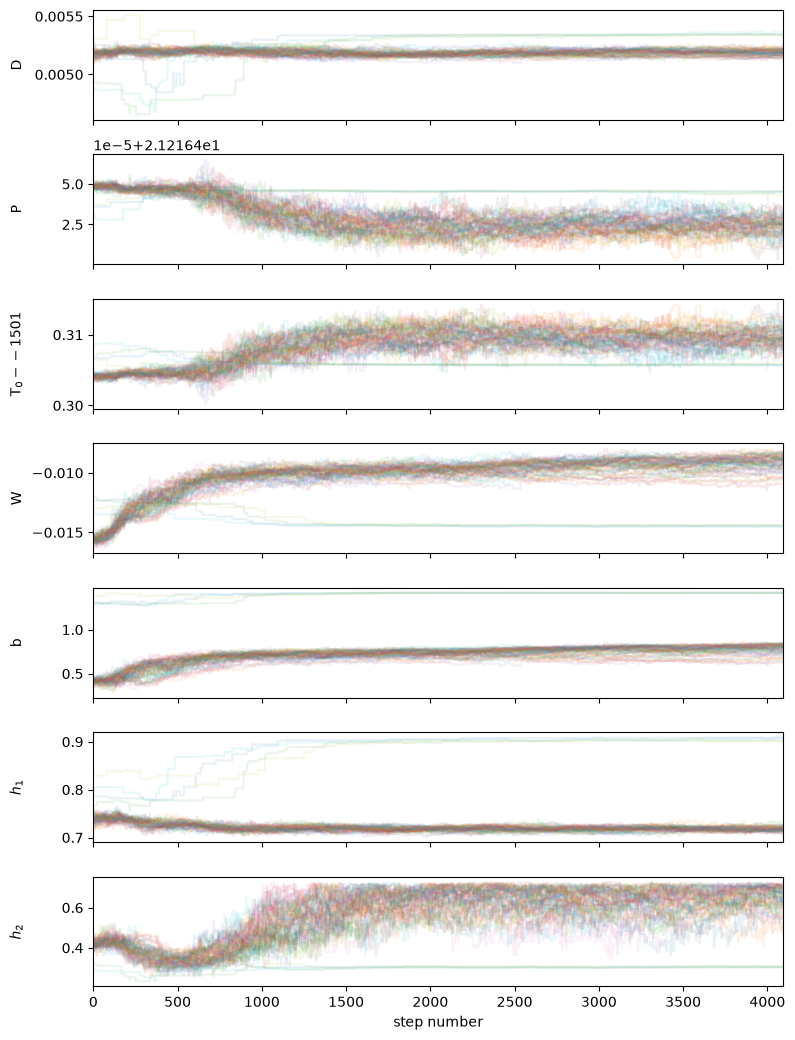

In [42]:
fig = M.trail_plot()
fig.savefig("trail_plot.pdf", bbox_inches="tight")

Plot a corner plot:

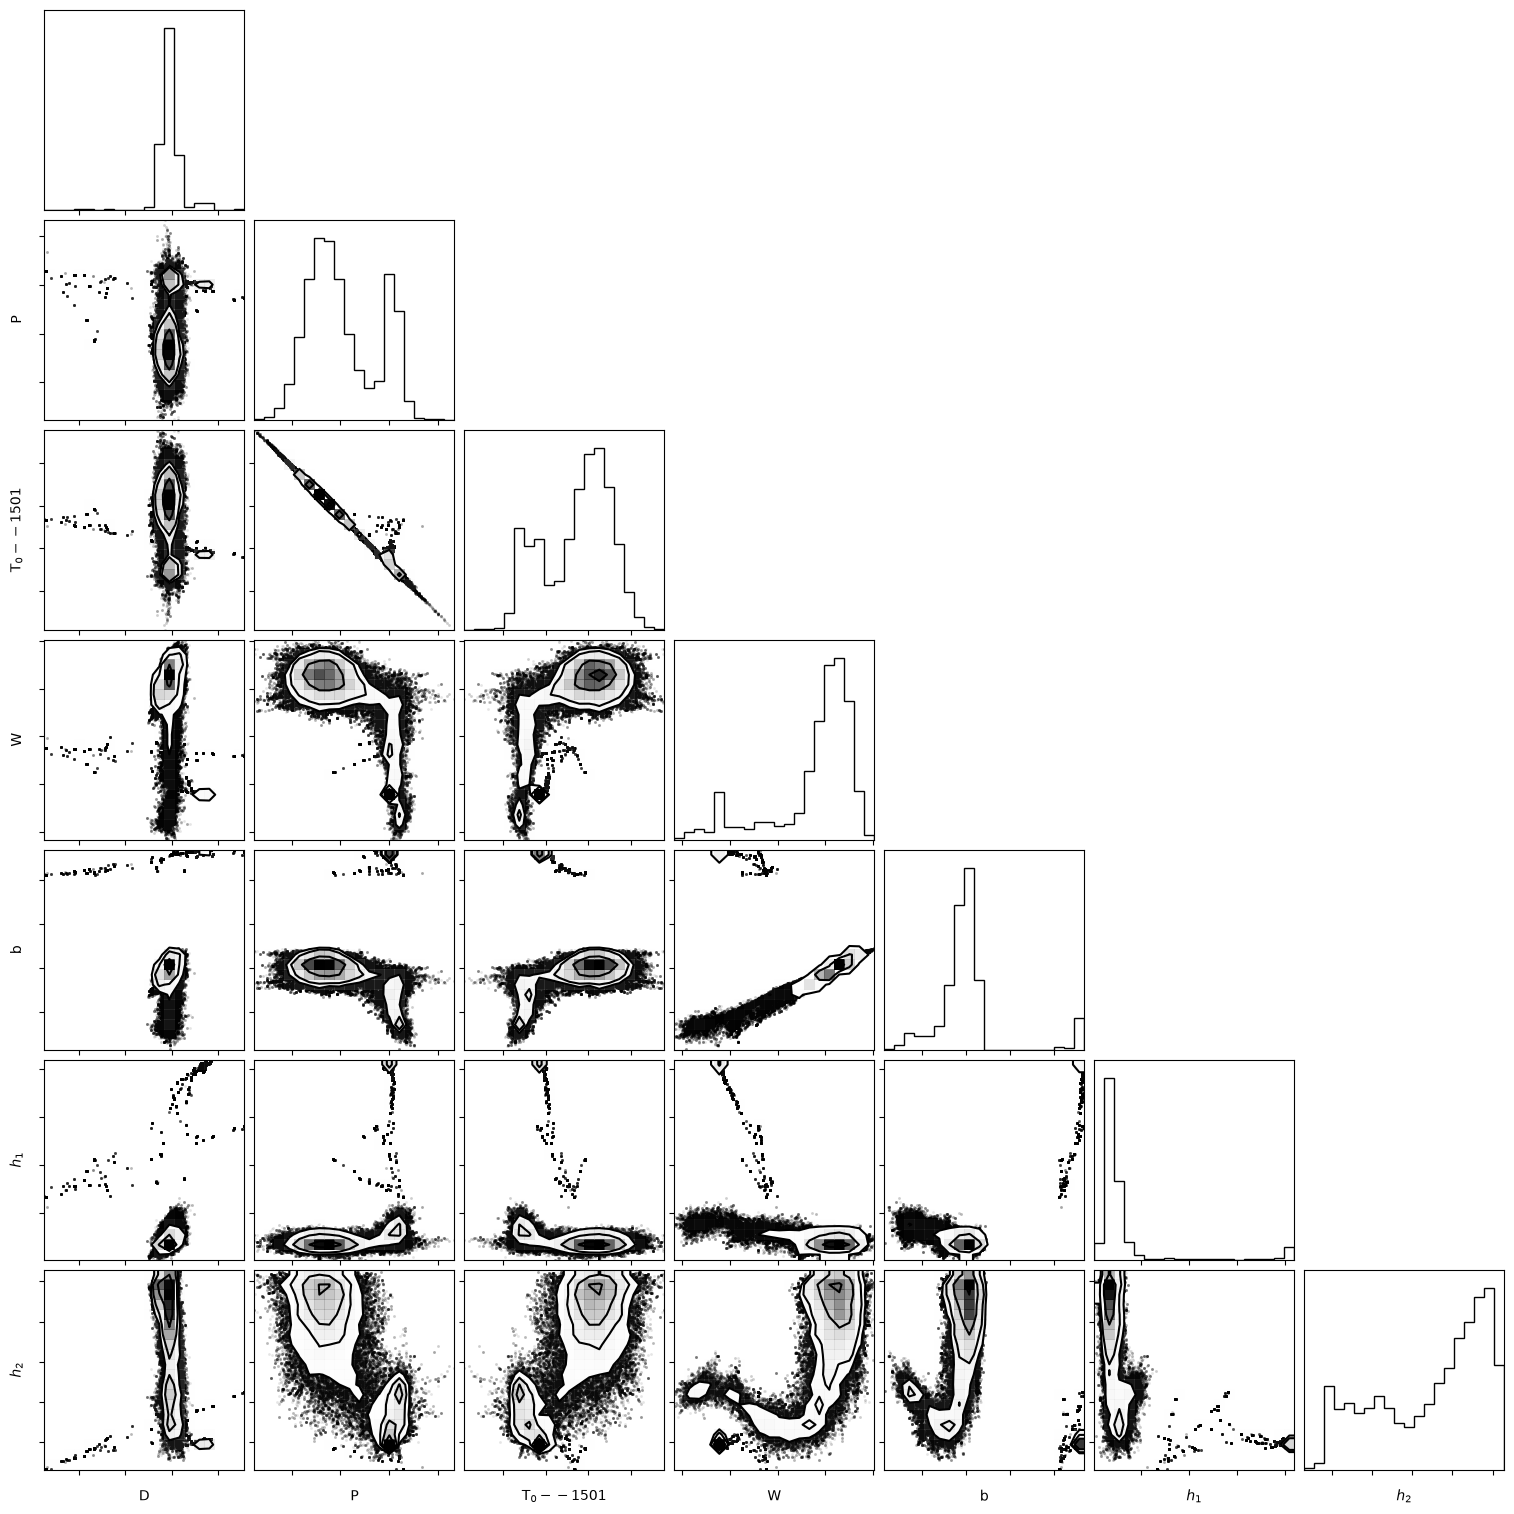

In [43]:
fig = M.corner_plot()
fig.savefig("corner_plot.pdf", bbox_inches="tight")

Print results (the option ``min_correl`` restricts the number of parameter correlation values in the report):

In [44]:
fit_report = M.fit_report(min_correl=0.5)
print(fit_report)

with open("fit_report.txt", "w", encoding="utf-8") as file:
    file.write(fit_report)

[[Fit Statistics]]
    # fitting method   = emcee
    # function evals   = 1194539
    # data points      = 2449
    # variables        = 20
    chi-square         = 3583.63532
    reduced chi-square = 1.47535419
    Akaike info crit   = -34282.7560
    Bayesian info crit = -34166.6873
    RMS residual       = 199.0 ppm
[[Variables]]
    D:               0.00518902 +/- 2.8111e-05 (0.54%) (init = 0.005556212)
    W:              -0.00983476 +/- 0.00149625 (15.21%) (init = -0.01273704)
    b:               0.73910613 +/- 0.07777446 (10.52%) (init = 1)
    P:               21.2164280 +/- 1.2545e-05 (0.00%) (init = 21.21644)
    T_0:            -1500.69123 +/- 0.00269950 (0.00%) (init = -1500.694)
    f_c:            -0.43371168 +/- 0.01511242 (3.48%) (init = -0.4324164)
    f_s:             0.70016072 +/- 0.00608327 (0.87%) (init = 0.6998686)
    l_3:             0 (fixed)
    h_1:             0.71992874 +/- 0.00740978 (1.03%) (init = 0.731805)
    h_2:             0.59004440 +/- 0.155353

Option to save ``.multivisit`` file again:

In [45]:
M.save(tag=new_tag, overwrite = True)

'HD_17156_analysis.multivisit'

In [46]:
# Check MCMC convergence diagnostics.
sampler = M.__sampler__
chain = sampler.get_chain()
acceptance_fraction = np.mean(sampler.acceptance_fraction)
print(f"Chain shape: {chain.shape}")
print(f"Mean acceptance fraction: {acceptance_fraction:.3f}")

try:
    tau = sampler.get_autocorr_time(tol=0)
    effective_samples = chain.shape[0] * chain.shape[1] / tau
    print(f"Autocorrelation time range: {tau.min():.1f} to {tau.max():.1f} steps")
    print(f"Effective samples range: {effective_samples.min():.0f} to {effective_samples.max():.0f}")
    print(f"Chain/tau range: {(chain.shape[0] / tau).min():.1f} to {(chain.shape[0] / tau).max():.1f}")
except Exception as error:
    print(f"Autocorrelation time unavailable: {type(error).__name__}: {error}")


Chain shape: (4096, 64, 20)
Mean acceptance fraction: 0.219
Autocorrelation time range: 214.2 to 509.3 steps
Effective samples range: 515 to 1224
Chain/tau range: 8.0 to 19.1
